In [1]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

train = pd.read_csv('../data/train.csv').drop(columns='ID')
X_train = train.drop(columns='y')
y_train = train['y']

X_test = pd.read_csv('../data/test.csv').drop(columns='ID')

In [2]:
scaler = MinMaxScaler()
X_train, X_test = scaler.fit_transform(X_train), scaler.transform(X_test)
X_train, X_test  = pd.DataFrame(X_train), pd.DataFrame(X_test)

In [3]:
# Data 준비
train_loader = DataLoader(TensorDataset(torch.Tensor(X_train.values), torch.Tensor(y_train.values)), batch_size= 64, shuffle=True)

In [6]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim*2) # mean, 
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu+eps*std
    
    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = h.chunk(2, dim=-1) #TODO : 왜 -1??
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

In [15]:
from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.utils import use_named_args


# 하이퍼파라미터 공간 정의
space  = [Real(1e-6, 1e-2, "log-uniform", name='learning_rate'),
          Integer(16, 256, name='hidden_dim'),
          Integer(2, 10, name='latent_dim'),
          Integer(50, 300, name='epochs')]

# 목적함수 정의
@use_named_args(space)
def objective(**params):
    input_dim = X_train.shape[1]
    learning_rate = params['learning_rate']
    hidden_dim = params['hidden_dim']
    latent_dim = params['latent_dim']
    epochs = params['epochs']
    
    # 모델 정의
    vae = VAE(input_dim, hidden_dim, latent_dim)
    optimizer =torch.optim.Adam(vae.parameters(), lr = learning_rate)
    reconstruction_loss = nn.MSELoss()
    
    # 모델 학습
    for epoch in range(epochs):
        for batch_X, _ in train_loader:
            optimizer.zero_grad()
            recon_batch, mu, logvar = vae(batch_X)
            recon_loss = reconstruction_loss(recon_batch, batch_X)
            kl_loss = -0.5*torch.sum(1+logvar - mu.pow(2) - logvar.exp())
            loss = recon_loss = kl_loss
            loss.backward()
            optimizer.step()
            
    with torch.no_grad():
        recon_data, _, _ = vae(torch.Tensor(X_train.values))
        recon_error = ((recon_data - torch.Tensor(X_train.values))**2).mean().item()
    
    return recon_error

res_gp = gp_minimize(objective, space, n_calls=20, random_state=0)

# 최적의 하이퍼파라미터 
best_params = {dim.name : value for dim, value in zip(space, res_gp.x)}
best_params

{'learning_rate': 2.9714344857244978e-05,
 'hidden_dim': 246,
 'latent_dim': 3,
 'epochs': 268}

In [7]:
# hyperparameter
# input_dim = X_train.shape[1]
# hidden_dim = best_params['hidden_dim']
# latent_dim = best_params['latent_dim']
# epochs = best_params['epochs']
# batch_size = 32
# learning_rate = best_params['learning_rate']

input_dim = X_train.shape[1]
hidden_dim = 246
latent_dim = 3
epochs = 268
batch_size = 32
learning_rate = 2.9714344857244978e-05

In [8]:
# 모델 초기화
vae = VAE(input_dim, hidden_dim, latent_dim)
optimizer = torch.optim.Adam(vae.parameters(), lr=learning_rate)
reconstruction_loss = nn.MSELoss()

In [9]:
# 모델 학습
for epoch in range(epochs):
    for batch_X, _ in train_loader:
        optimizer.zero_grad()
        recon_batch, mu, logvar = vae(batch_X)
        recon_loss = reconstruction_loss(recon_batch, batch_X)
        kl_loss = -0.5 * torch.sum(1+logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + kl_loss
        loss.backward()
        optimizer.step()
    if epoch % 10 == 0:
        print(f'epoch {epoch} : loss {loss.item()}')

epoch 0 : loss 0.07224859297275543
epoch 10 : loss 0.0312320739030838
epoch 20 : loss 0.02409239485859871
epoch 30 : loss 0.03665793687105179
epoch 40 : loss 0.042693909257650375
epoch 50 : loss 0.035657141357660294
epoch 60 : loss 0.03424396365880966
epoch 70 : loss 0.05202483758330345
epoch 80 : loss 0.03137386590242386
epoch 90 : loss 0.03295350819826126
epoch 100 : loss 0.042216408997774124
epoch 110 : loss 0.027493508532643318
epoch 120 : loss 0.03258881717920303
epoch 130 : loss 0.028965463861823082
epoch 140 : loss 0.042211033403873444
epoch 150 : loss 0.02919783629477024
epoch 160 : loss 0.04020599275827408
epoch 170 : loss 0.04268835857510567
epoch 180 : loss 0.02973964996635914
epoch 190 : loss 0.04391409084200859
epoch 200 : loss 0.0364009328186512
epoch 210 : loss 0.03893536329269409
epoch 220 : loss 0.03882657736539841
epoch 230 : loss 0.03471643477678299
epoch 240 : loss 0.02933507040143013
epoch 250 : loss 0.038008131086826324
epoch 260 : loss 0.04381394013762474


In [8]:
# 잠재 변수 생성
with torch.no_grad():
    h = vae.encoder(torch.Tensor(X_train.values))
    latent_values, _ = h.chunk(2, dim=-1)
    
# PCA로 latent space 시각화(2D)
latent_values = latent_values.numpy()
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_values)

In [9]:
# decoder의 uncertainty 계산
with torch.no_grad():
    recon_data, mu, logvar = vae(torch.Tensor(X_train.values))
    recon_error = ((recon_data - torch.Tensor(X_train.values))**2).mean(dim=1)
    uncertainty = logvar.exp().mean(dim=1).numpy()

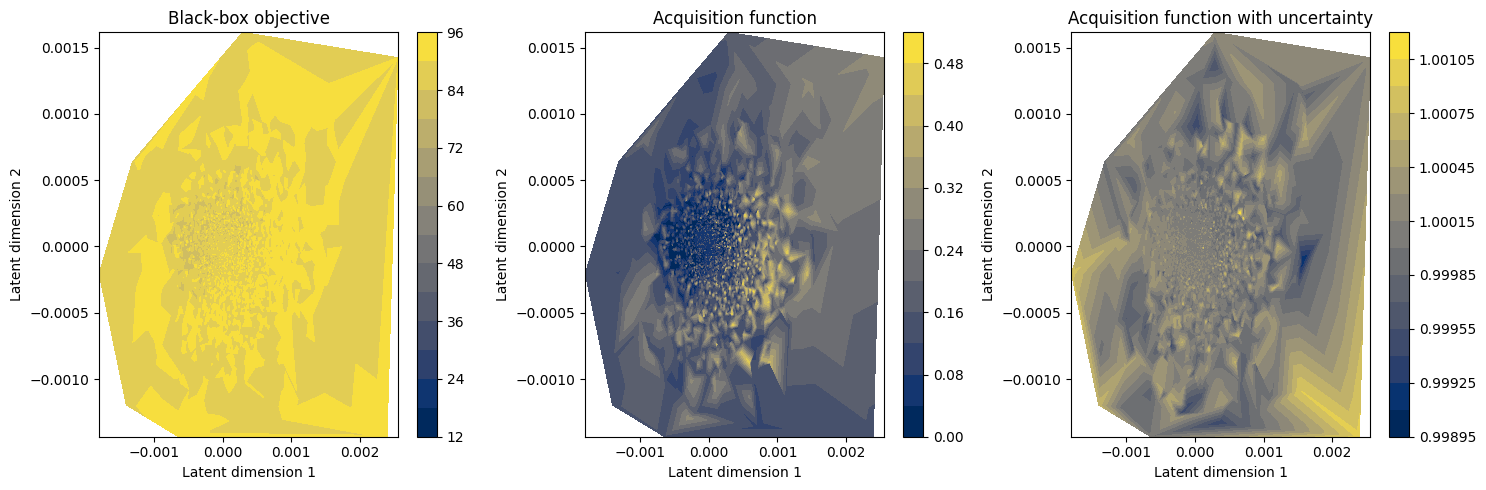

In [10]:
# visualization
plt.figure(figsize=(15,5))

# black-box objective
plt.subplot(1,3,1)
plt.tricontourf(latent_2d[:,0], latent_2d[:,1], y_train, levels= 14, cmap='cividis')
plt.colorbar()
plt.title('Black-box objective')
plt.xlabel('Latent dimension 1')
plt.ylabel('Latent dimension 2')

# Acquisition function
plt.subplot(1,3,2)
plt.tricontourf(latent_2d[:,0], latent_2d[:,1], recon_error.numpy(), levels= 14, cmap='cividis')
plt.colorbar()
plt.title('Acquisition function')
plt.xlabel('Latent dimension 1')
plt.ylabel('Latent dimension 2')

# Acquisition function with uncertainty
plt.subplot(1,3,3)
plt.tricontourf(latent_2d[:,0], latent_2d[:,1], uncertainty, levels= 14, cmap='cividis')
plt.colorbar()
plt.title('Acquisition function with uncertainty')
plt.xlabel('Latent dimension 1')
plt.ylabel('Latent dimension 2')


plt.tight_layout()
plt.show()

In [10]:
pip install scikit-optimize

Note: you may need to restart the kernel to use updated packages.


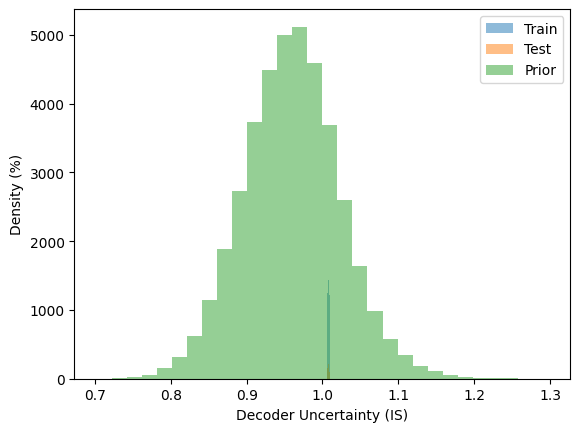

In [35]:
def calculate_uncertainty(vae, X, num_samples=100):
    uncertainties = []
    
    for _ in range(num_samples):
        with torch.no_grad():
            h = vae.encoder(torch.Tensor(X))
            mu, logvar = h.chunk(2, dim=-1)
            theta = vae.reparameterize(mu, logvar)
            reconstruction = vae.decoder(theta)
            uncertainty = logvar.exp().mean(dim=1).numpy()
            uncertainties.append(uncertainty)
    
    return np.mean(uncertainties, axis=0)

# Calculate uncertainty for train, test, prior, and far from prior
train_uncertainty = calculate_uncertainty(vae, X_train.values)
test_uncertainty = calculate_uncertainty(vae, X_test.values)

# For prior: Sample from the prior distribution in the latent space
# VAE 인코더의 입력 차원에 맞추어 샘플 크기를 수정
prior_samples = np.random.normal(size=(X_train.shape[0], X_train.shape[1]))
prior_uncertainty = calculate_uncertainty(vae, prior_samples)

# For far from prior: Sample from a distribution far from the prior (e.g., 10x std deviation)
far_from_prior_samples = np.random.normal(loc=0, scale=5, size=(X_train.shape[0], X_train.shape[1]))
far_from_prior_uncertainty = calculate_uncertainty(vae, far_from_prior_samples)

# Plotting the uncertainty distribution
plt.hist(train_uncertainty, bins=30, alpha=0.5, label='Train')
plt.hist(test_uncertainty, bins=30, alpha=0.5, label='Test')
plt.hist(prior_uncertainty, bins=30, alpha=0.5, label='Prior')
# plt.hist(far_from_prior_uncertainty, bins=30, alpha=0.5, label='Far from prior')
plt.xlabel('Decoder Uncertainty (IS)')
plt.ylabel('Density (%)')
plt.legend()
# plt.yscale('log')
plt.show()


In [ ]:
import torch
import numpy as np

def importance_sampling_mi(vae, X, N=100, M=50):
    mi_estimates = []
    
    for s in range(N):
        with torch.no_grad():
            h = vae.encoder(torch.Tensor(X))
            mu, logvar = h.chunk(2, dim=-1)
            theta_0 = vae.reparameterize(mu, logvar)
            y_s = vae.decoder(theta_0)
        
        ps_list = []
        hs_list = []

        for m in range(M):
            theta_m = vae.reparameterize(mu, logvar)
            p_s_m = torch.exp(-torch.sum((y_s - vae.decoder(theta_m)) ** 2, dim=1))  # 가정된 p(y|x,θ)
            ps_list.append(p_s_m)
            hs_list.append(p_s_m * torch.log(p_s_m))
        
        ps = torch.mean(torch.stack(ps_list), dim=0)
        hs = torch.mean(torch.stack(hs_list), dim=0) - ps * torch.log(ps)
        mi_estimates.append(hs / ps)
    
    return torch.mean(torch.stack(mi_estimates)).item()

# 데이터와 VAE 모델을 사용해 MI를 계산
mi_value = importance_sampling_mi(vae, X_train.values)
print("Estimated Mutual Information:", mi_value)



: 

In [10]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 잠재 변수 추출
with torch.no_grad():
    latent_values = vae.encoder(torch.Tensor(X_train.values)).chunk(2, dim=-1)[0].numpy()

# PCA를 사용해 잠재 변수를 2차원으로 축소
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_values)

# MI 값을 기준으로 색상 매핑
plt.figure(figsize=(10, 7))
plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=mi_value, cmap='viridis', s=5)
plt.colorbar(label='Mutual Information')
plt.title('Latent Space with Mutual Information')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.show()


NameError: name 'mi_value' is not defined

<Figure size 1000x700 with 0 Axes>

In [ ]:
# visualization
plt.figure(figsize=(15,5))

# black-box objective
plt.subplot(1,3,1)
plt.tricontourf(latent_2d[:,0], latent_2d[:,1], y_train, levels= 14, cmap='cividis')
plt.colorbar()
plt.title('Black-box objective')
plt.xlabel('Latent dimension 1')
plt.ylabel('Latent dimension 2')

# Acquisition function
plt.subplot(1,3,2)
plt.tricontourf(latent_2d[:,0], latent_2d[:,1], recon_error.numpy(), levels= 14, cmap='cividis')
plt.colorbar()
plt.title('Acquisition function')
plt.xlabel('Latent dimension 1')
plt.ylabel('Latent dimension 2')

# Acquisition function with uncertainty
plt.subplot(1,3,3)
plt.tricontourf(latent_2d[:,0], latent_2d[:,1], uncertainty, levels= 14, cmap='cividis')
plt.colorbar()
plt.title('Acquisition function with uncertainty')
plt.xlabel('Latent dimension 1')
plt.ylabel('Latent dimension 2')


plt.tight_layout()
plt.show()